# Conformal Prediction Analysis (from cached predictions)

This notebook performs the full conformal prediction analysis using cached predictions saved by the training notebook. It does **no** model training or inference — it loads the six `.npy` files from `cache/` and computes everything from there.

Because there is no randomness in training or inference here, this notebook is **fully reproducible**: every run produces byte-identical results.

**Required files in `cache/`:**
- `y_pred_norm_cal.npy`  — model predictions on synthetic calibration set, shape (200, 1024)
- `y_true_norm_cal.npy`  — ground truth for synthetic calibration set, shape (200, 1024)
- `y_pred_norm_eval.npy` — model predictions on synthetic evaluation set, shape (200, 1024)
- `y_true_norm_eval.npy` — ground truth for synthetic evaluation set, shape (200, 1024)
- `y_pred_real.npy`      — model predictions on real solvents, shape (6, 1024)
- `y_true_real.npy`      — ground truth on real solvents, shape (6, 1024)

## Step 1 — Load cached predictions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Reproducibility for the logistic regression
SEED = 42
np.random.seed(SEED)

CACHE_DIR = "cache"

required_files = [
    "y_pred_norm_cal.npy",
    "y_true_norm_cal.npy",
    "y_pred_norm_eval.npy",
    "y_true_norm_eval.npy",
    "y_pred_real.npy",
    "y_true_real.npy",
]

missing = [f for f in required_files if not os.path.exists(os.path.join(CACHE_DIR, f))]
if missing:
    raise FileNotFoundError(
        f"Missing cache files: {missing}. "
        f"Run the training notebook first to generate them in '{CACHE_DIR}/'."
    )

y_pred_norm_cal  = np.load(f"{CACHE_DIR}/y_pred_norm_cal.npy")
y_true_norm_cal  = np.load(f"{CACHE_DIR}/y_true_norm_cal.npy")
y_pred_norm_eval = np.load(f"{CACHE_DIR}/y_pred_norm_eval.npy")
y_true_norm_eval = np.load(f"{CACHE_DIR}/y_true_norm_eval.npy")
y_pred_real      = np.load(f"{CACHE_DIR}/y_pred_real.npy")
y_true_real      = np.load(f"{CACHE_DIR}/y_true_real.npy")

print("Loaded predictions from cache:")
print(f"  y_pred_norm_cal:  {y_pred_norm_cal.shape}")
print(f"  y_true_norm_cal:  {y_true_norm_cal.shape}")
print(f"  y_pred_norm_eval: {y_pred_norm_eval.shape}")
print(f"  y_true_norm_eval: {y_true_norm_eval.shape}")
print(f"  y_pred_real:      {y_pred_real.shape}")
print(f"  y_true_real:      {y_true_real.shape}")

Loaded predictions from cache:
  y_pred_norm_cal:  (200, 1024)
  y_true_norm_cal:  (200, 1024)
  y_pred_norm_eval: (200, 1024)
  y_true_norm_eval: (200, 1024)
  y_pred_real:      (6, 1024)
  y_true_real:      (6, 1024)


In [2]:
alpha = 0.1
scores_cal = np.abs(y_true_norm_cal - y_pred_norm_cal)

q = np.quantile(scores_cal, 1 - alpha, axis=0)

In [3]:
lower = y_pred_real - q
upper = y_pred_real + q


In [4]:
LEN =   656

y_true_s = y_true_real[:, :LEN]
y_pred_s = y_pred_real[:, :LEN]
lower_s  = lower[:,  :LEN]
upper_s  = upper[:,  :LEN]


In [5]:
covered = (y_true_real >= lower) & (y_true_real <= upper)

coverage_overall = covered.mean()
coverage_per_spectrum = covered.mean(axis=1)

print("Overall coverage:", coverage_overall)
for i, c in enumerate(coverage_per_spectrum):
    print(f"Spectrum {i} coverage:", c)


Overall coverage: 0.85400390625
Spectrum 0 coverage: 0.8359375
Spectrum 1 coverage: 0.9130859375
Spectrum 2 coverage: 0.8330078125
Spectrum 3 coverage: 0.80078125
Spectrum 4 coverage: 0.927734375
Spectrum 5 coverage: 0.8134765625


## Step 2 — Logistic regression classifier for importance weights

The classifier learns to distinguish synthetic calibration predictions (label 0) from real predictions (label 1). The weights are then computed as the odds ratio:

$$w_i = \frac{p(\text{label}=1 \mid x_i)}{1 - p(\text{label}=1 \mid x_i) + \varepsilon}$$

In [6]:
# Reshape predictions into flat feature vectors
Xs = y_pred_norm_cal.reshape(len(y_pred_norm_cal), -1)   # synthetic calibration
Xr = y_pred_real.reshape(len(y_pred_real), -1)            # real
Xt = y_pred_norm_eval.reshape(len(y_pred_norm_eval), -1)  # synthetic evaluation

# Build classifier dataset: synthetic (0) vs real (1)
X_clf = np.vstack([Xs, Xr])
y_clf = np.hstack([
    np.zeros(len(Xs)),  # synthetic
    np.ones(len(Xr)),   # real
])

clf = LogisticRegression(max_iter=300, random_state=SEED)
clf.fit(X_clf, y_clf)

# Probability that each evaluation sample belongs to the real distribution
p_real = clf.predict_proba(Xt)[:, 1]

# Importance weights (odds ratio)
weights = p_real / (1 - p_real + 1e-8)

print("Shape of Xs (synthetic cal):", Xs.shape)
print("Shape of Xr (real):         ", Xr.shape)
print("Shape of X_clf:             ", X_clf.shape)
print("Range of weights:           ", weights.min(), "to", weights.max())

Shape of Xs (synthetic cal): (200, 1024)
Shape of Xr (real):          (6, 1024)
Shape of X_clf:              (206, 1024)
Range of weights:            4.2121499931025605e-05 to 0.41560506161760136


## Step 3 — Conformal prediction

**Nonconformity score:** absolute residual at each wavelength.

**Unweighted quantile** at level $1-\alpha$ on the flattened calibration score array.

**Weighted quantile** at the same level, with per-spectrum weights repeated across all wavelengths.

In [7]:
def weighted_quantile(scores, weights, alpha):
    """Compute the (1 - alpha) weighted quantile of `scores` using `weights`."""
    idx = np.argsort(scores)
    s = scores[idx]
    w = weights[idx]

    cum_w = np.cumsum(w)
    cutoff = (1 - alpha) * cum_w[-1]

    return s[np.searchsorted(cum_w, cutoff)]

In [8]:
alpha = 0.1

# Per-point nonconformity scores on the synthetic calibration set
# shape: (N_cal, wavelengths)
scores_matrix = np.abs(y_true_norm_cal - y_pred_norm_cal)

# Flatten to (N_cal * wavelengths,)
scores_cal = scores_matrix.ravel()

# Unweighted quantile
q_unweighted = np.quantile(scores_cal, 1 - alpha)

# Weighted quantile: repeat each spectrum's weight for all wavelengths
n_wavelengths = y_true_norm_cal.shape[1]
weights_expanded = np.repeat(weights, n_wavelengths)  # shape: 200 * 1024 = 204800
q_weighted = weighted_quantile(scores_cal, weights_expanded, alpha)

print(f"Unweighted q: {q_unweighted}")
print(f"Weighted q:   {q_weighted}")

Unweighted q: 0.07921489334414507
Weighted q:   0.0900742532621756


## Step 4 — Coverage evaluation

**Real data coverage:** fraction of points in `y_true_real` that fall within the prediction intervals constructed using each quantile.

**Synthetic coverage:** same, on the held-out synthetic calibration scores (sanity check — should be ~0.9 for unweighted).

In [9]:
# Point-wise coverage on REAL data
scores_real = np.abs(y_true_s - y_pred_s).ravel()

covered_unweighted = scores_real <= q_unweighted
covered_weighted   = scores_real <= q_weighted

coverage_unweighted = covered_unweighted.mean()
coverage_weighted   = covered_weighted.mean()

print("Point-wise coverage on REAL data:")
print(f"  Unweighted: {coverage_unweighted}")
print(f"  Weighted:   {coverage_weighted}")

Point-wise coverage on REAL data:
  Unweighted: 0.8013211382113821
  Weighted:   0.8379065040650406


In [10]:
# Point-wise coverage on SYNTHETIC calibration data (sanity check)
cov_syn_unweighted = (scores_cal <= q_unweighted).mean()
cov_syn_weighted   = (scores_cal <= q_weighted).mean()

print("Synthetic coverage:")
print(f"  Unweighted: {cov_syn_unweighted}")
print(f"  Weighted:   {cov_syn_weighted}")

Synthetic coverage:
  Unweighted: 0.9
  Weighted:   0.921904296875


## Step 5 — Bar plot: coverage comparison

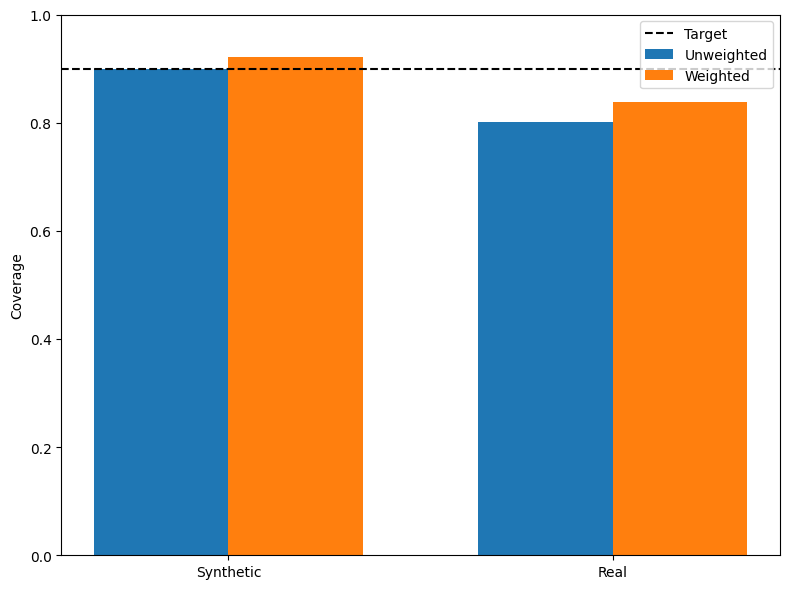

Saved figure to coverage_bar_plot.png


In [11]:
labels = ["Synthetic", "Real"]
unweighted_values = [cov_syn_unweighted, coverage_unweighted]
weighted_values   = [cov_syn_weighted,   coverage_weighted]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, unweighted_values, width, label="Unweighted")
ax.bar(x + width/2, weighted_values,   width, label="Weighted")

ax.axhline(1 - alpha, linestyle="--", color="k", label="Target")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Coverage")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("coverage_bar_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure to coverage_bar_plot.png")

## Summary of results

Final numerical results, suitable for copying into Section 5 of the report:

In [12]:
print("=" * 60)
print("CONFORMAL PREDICTION RESULTS")
print("=" * 60)
print(f"Target coverage level (1 - alpha): {1 - alpha:.2f}")
print()
print("Quantile thresholds:")
print(f"  q_unweighted = {q_unweighted:.6f}")
print(f"  q_weighted   = {q_weighted:.6f}")
print()
print("Synthetic coverage:")
print(f"  Unweighted: {cov_syn_unweighted:.4f} ({cov_syn_unweighted*100:.2f}%)")
print(f"  Weighted:   {cov_syn_weighted:.4f}   ({cov_syn_weighted*100:.2f}%)")
print()
print("Real coverage:")
print(f"  Unweighted: {coverage_unweighted:.4f} ({coverage_unweighted*100:.2f}%)")
print(f"  Weighted:   {coverage_weighted:.4f}   ({coverage_weighted*100:.2f}%)")
print()
improvement_pp = (coverage_weighted - coverage_unweighted) * 100
print(f"Improvement on real data: {improvement_pp:+.2f} percentage points")
print("=" * 60)

CONFORMAL PREDICTION RESULTS
Target coverage level (1 - alpha): 0.90

Quantile thresholds:
  q_unweighted = 0.079215
  q_weighted   = 0.090074

Synthetic coverage:
  Unweighted: 0.9000 (90.00%)
  Weighted:   0.9219   (92.19%)

Real coverage:
  Unweighted: 0.8013 (80.13%)
  Weighted:   0.8379   (83.79%)

Improvement on real data: +3.66 percentage points


In [13]:

# Combined Raman training + prediction + Uncertainty analysis
# Original code structure preserved; only np.save/np.load lines are commented/rewired

# Import some libraries

import torch
from torch.utils.data import Dataset, DataLoader, random_split, Subset

import numpy as np
import numpy as np
import tifffile

# import tensorly as tl
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.fft
import torch.optim as optim

# Ensure you have the correct path to your data files
# Load the synthetic CARS and Raman spectra data
raw_cars = np.load("cars_2000x1024.npy")
raman = np.load("raman_2000x1024.npy")
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)







Using device: mps


In [14]:
class SpectraDataset(Dataset):
    def __init__(self, cars, raman, scale_type="minmax"):
        """
        Args:
            cars (np.array): Array of CARS spectra, shape (N, s)
            raman (np.array): Array of Raman spectra, shape (N, s)
            scale_type (str): Scaling method ('minmax', 'standard', 'log')
        """
        self.scale_type = scale_type

        # Apply scaling
        if scale_type == "minmax":
            self.cars = self.minmax_scale(cars)
            self.raman = self.minmax_scale(raman)
        elif scale_type == "standard":
            self.cars = self.standardize(cars)
            self.raman = self.standardize(raman)
        elif scale_type == "log":
            self.cars = self.log_transform(cars)
            self.raman = self.log_transform(raman)
        elif scale_type == "none":
            self.cars = cars
            self.raman = raman
        else:
            raise ValueError(
                "Invalid scale_type. Choose from ['minmax', 'standard', 'log']"
            )

        # Convert to torch tensors
        self.cars = torch.tensor(self.cars, dtype=torch.float32)
        self.raman = torch.tensor(self.raman, dtype=torch.float32)

    def minmax_scale(self, data):
        return (data - np.min(data, axis=0)) / (np.max(data, axis=0) - np.min(data, axis=0))

    def standardize(self, data):
        return (data - np.mean(data, axis=0)) / np.std(data, axis=0)

    def log_transform(self, data):
        return np.log1p(data)

    def __len__(self):
        return self.cars.shape[0]

    def __getitem__(self, idx):
        return self.cars[idx], self.raman[idx]



In [15]:
# Create the dataset
dataset = SpectraDataset(raw_cars, raman)

# Split into train and test sets (e.g., 80% train, 20% test)
train_ratio = 0.8
train_size = int(train_ratio * len(dataset)) # e.g. 1600
test_size = len(dataset) - train_size  # e.g. 400

all_indices   = np.arange(len(dataset))
train_indices = all_indices[:train_size]    # 0 ... 1599
test_indices  = all_indices[train_size:]    # 1600 ... 1999

# save test indices (for y_true later)
# np.save(r"C:\Users\mukhe\OneDrive\Desktop\INTERNSHIP REPORT\test_indices.npy",
#         test_indices)  # commented out to avoid saving to disk


# raw numpy arrays
cars_raw = raw_cars
raman_raw = raman


# extract raw train/test
cars_train = cars_raw[train_indices]
raman_train = raman_raw[train_indices]

cars_test = cars_raw[test_indices]
raman_test = raman_raw[test_indices]

# build Subset datasets using these indices
train_dataset = Subset(dataset, train_indices)
test_dataset  = Subset(dataset, test_indices)

# Create DataLoaders for batching
batch_size = 32



train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,           # set to 0 for full reproducibility, or use seed_worker
)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Example: iterate over one batch from the training loader and print shapes
for cars_batch, raman_batch in train_loader:
    print("#")
    print("CARS batch shape:", cars_batch.shape)  # should be (batch_size, s)
    print("Raman batch shape:", raman_batch.shape)  # should be (batch_size, s)
    break
print(device)


#
CARS batch shape: torch.Size([32, 1024])
Raman batch shape: torch.Size([32, 1024])
mps


In [16]:
# Real solvents data
cars_real_raw = np.load("dataset_Mukesh/dataset_Mukesh/CARS_solvents_all.npy")
raman_real    = np.load("dataset_Mukesh/dataset_Mukesh/RAMAN_solvents_all.npy")
wn            = np.load("dataset_Mukesh/dataset_Mukesh/Raman_solvent_wavenumber.npy")

# Need training-set min/max to put real CARS in the same space the model sees
raw_cars = np.load("cars_2000x1024.npy")
cars_train      = raw_cars[:1600]
cars_min_train  = cars_train.min(axis=0)
cars_max_train  = cars_train.max(axis=0)

# THIS is the actual cars_real_norm — properly normalized
cars_real_norm = (cars_real_raw - cars_min_train) / (cars_max_train - cars_min_train + 1e-8)

print("cars_real_norm shape:", cars_real_norm.shape)
print("raman_real shape:", raman_real.shape)
print("wn shape:", wn.shape)


cars_real_norm shape: (6, 1024)
raman_real shape: (6, 656)
wn shape: (656,)


In [17]:
# Split the test set (400 samples) into calibration (200) and evaluation (200)
# Use the same indexing logic as the existing code

cal_size  = 200
eval_size = test_size - cal_size  # 200

cal_indices  = test_indices[:cal_size]            # 1600 ... 1799
eval_indices = test_indices[cal_size:]            # 1800 ... 1999

# Extract raw CARS for each subset
X_cars_synthetic_cal  = cars_raw[cal_indices]     # 200 x 1024 (or whatever spectrum length)
X_cars_synthetic_eval = cars_raw[eval_indices]    # 200 x 1024

# Extract raw Raman for each subset (you may already have these elsewhere)
y_true_synthetic_cal  = raman_raw[cal_indices]    # 200 x 1024
y_true_synthetic_eval = raman_raw[eval_indices]   # 200 x 1024

# Verify shapes
print("X_cars_synthetic_cal shape: ", X_cars_synthetic_cal.shape)
print("X_cars_synthetic_eval shape:", X_cars_synthetic_eval.shape)
print("y_true_synthetic_cal shape: ", y_true_synthetic_cal.shape)
print("y_true_synthetic_eval shape:", y_true_synthetic_eval.shape)

X_cars_synthetic_cal shape:  (200, 1024)
X_cars_synthetic_eval shape: (200, 1024)
y_true_synthetic_cal shape:  (200, 1024)
y_true_synthetic_eval shape: (200, 1024)


In [18]:
import numpy as np
from sklearn.linear_model import LogisticRegression

def weighted_quantile(scores, weights, alpha):
    """
    Compute the (1 - alpha) weighted quantile of scores.
    
    Parameters
    ----------
    scores : array-like
        Nonconformity scores
    weights : array-like
        Importance weights (same length as scores)
    alpha : float
        Significance level (e.g., 0.1 for 90% coverage)
    
    Returns
    -------
    float : the weighted quantile threshold
    """
    idx = np.argsort(scores)
    s = scores[idx]
    w = weights[idx]
    
    cum_w = np.cumsum(w)
    cutoff = (1 - alpha) * cum_w[-1]
    
    return s[np.searchsorted(cum_w, cutoff)]

alpha = 0.1

In [19]:
# Scores are computed in the Raman space on the calibration set
# This is identical for both Option A and Option B
scores_matrix = np.abs(y_true_norm_cal - y_pred_norm_cal)
scores_cal = scores_matrix.ravel()

print(f"scores_cal shape: {scores_cal.shape}")

scores_cal shape: (204800,)


In [20]:
# === OPTION A: Classifier on Predicted Raman ===

# Step 1: Build classifier training data from predicted Raman
Xs_A = y_pred_norm_cal.reshape(len(y_pred_norm_cal), -1)   # 200 x 1024
Xr_A = y_pred_real.reshape(len(y_pred_real), -1)           # 6 x 1024
X_clf_A = np.vstack([Xs_A, Xr_A])

# Step 2: Binary labels (0 = synthetic, 1 = real)
y_clf = np.hstack([np.zeros(len(Xs_A)), np.ones(len(Xr_A))])

# Step 3: Train logistic regression
clf_A = LogisticRegression(max_iter=300, random_state=SEED)
clf_A.fit(X_clf_A, y_clf)

# Step 4: Extract weights — apply classifier to evaluation predictions
Xt_A = y_pred_norm_eval.reshape(len(y_pred_norm_eval), -1) # 200 x 1024
p_real_A = clf_A.predict_proba(Xt_A)[:, 1]
weights_A = p_real_A / (1 - p_real_A + 1e-8)

# Step 5: Expand weights and compute weighted quantile
weights_expanded_A = np.repeat(weights_A, y_true_norm_eval.shape[1])
q_weighted_A = weighted_quantile(scores_cal, weights_expanded_A, alpha)

print(f"Option A — Predicted Raman classifier:")
print(f"  Mean weight: {weights_A.mean():.4f}, Std: {weights_A.std():.4f}")
print(f"  Weighted quantile q_A: {q_weighted_A:.6f}")

Option A — Predicted Raman classifier:
  Mean weight: 0.0221, Std: 0.0486
  Weighted quantile q_A: 0.090074


In [21]:
# === OPTION B: Classifier on Raw CARS ===

# Step 1: Build classifier training data from RAW CARS
X_cars_synthetic_cal_norm = (X_cars_synthetic_cal - cars_min_train) / (cars_max_train - cars_min_train + 1e-8)
Xs_B = X_cars_synthetic_cal_norm.reshape(len(X_cars_synthetic_cal_norm), -1)
Xr_B = cars_real_norm.reshape(len(cars_real_norm), -1)                    # 6 x 1024
X_clf_B = np.vstack([Xs_B, Xr_B])

# Step 2: Binary labels (same as Option A)
y_clf = np.hstack([np.zeros(len(Xs_B)), np.ones(len(Xr_B))])

# Step 3: Train logistic regression on RAW CARS
clf_B = LogisticRegression(max_iter=300, random_state=SEED)
clf_B.fit(X_clf_B, y_clf)

# Step 4: Extract weights — apply classifier to evaluation CARS inputs
Xt_B = X_cars_synthetic_eval.reshape(len(X_cars_synthetic_eval), -1)
p_real_B = clf_B.predict_proba(Xt_B)[:, 1]
weights_B = p_real_B / (1 - p_real_B + 1e-8)

# Step 5: Scores stay the same as Option A (already computed in Cell 2)

# Step 6: Expand weights and compute weighted quantile
weights_expanded_B = np.repeat(weights_B, y_true_norm_eval.shape[1])
q_weighted_B = weighted_quantile(scores_cal, weights_expanded_B, alpha)

print(f"Option B — Raw CARS classifier:")
print(f"  Mean weight: {weights_B.mean():.4f}, Std: {weights_B.std():.4f}")
print(f"  Weighted quantile q_B: {q_weighted_B:.6f}")

Option B — Raw CARS classifier:
  Mean weight: 0.0063, Std: 0.0150
  Weighted quantile q_B: 0.077252


In [22]:
scores_real = np.abs(y_true_s - y_pred_s).ravel()

cov_real_A = (scores_real <= q_weighted_A).mean()
cov_real_B = (scores_real <= q_weighted_B).mean()

print(f"Option A (Predicted Raman) coverage on real data: {cov_real_A*100:.2f}%")
print(f"Option B (Raw CARS)        coverage on real data: {cov_real_B*100:.2f}%")
print(f"Difference: {abs(cov_real_A - cov_real_B)*100:.2f} percentage points")

Option A (Predicted Raman) coverage on real data: 83.79%
Option B (Raw CARS)        coverage on real data: 79.52%
Difference: 4.27 percentage points


In [23]:
# === UNWEIGHTED COVERAGE (sanity check) ===

# The unweighted quantile uses NumPy's standard quantile function
# It does not depend on the classifier — so it should be the same in both cases


print(f"Unweighted quantile q̂: {q_unweighted:.6f}")

# Coverage on real data using the unweighted quantile
scores_real = np.abs(y_true_s - y_pred_s).ravel()
cov_real_unweighted = (scores_real <= q_unweighted).mean()

print(f"Unweighted coverage on real data: {cov_real_unweighted*100:.2f}%")

# Coverage on synthetic evaluation data
cov_syn_unweighted = (scores_cal <= q_unweighted).mean()
print(f"Unweighted coverage on synthetic data: {cov_syn_unweighted*100:.2f}%")

Unweighted quantile q̂: 0.079215
Unweighted coverage on real data: 80.13%
Unweighted coverage on synthetic data: 90.00%


In [24]:
# === FULL COMPARISON: Unweighted vs Option A vs Option B ===

# Compute scores
scores_real = np.abs(y_true_s - y_pred_s).ravel()

# Unweighted quantile (does not depend on classifier)
q_unweighted = np.quantile(scores_cal, 1 - alpha)

# Coverage on real data
cov_real_unweighted = (scores_real <= q_unweighted).mean()
cov_real_A = (scores_real <= q_weighted_A).mean()
cov_real_B = (scores_real <= q_weighted_B).mean()

# Coverage on synthetic data (sanity check)
cov_syn_unweighted = (scores_cal <= q_unweighted).mean()
cov_syn_A = (scores_cal <= q_weighted_A).mean()
cov_syn_B = (scores_cal <= q_weighted_B).mean()

# Print a clean comparison table
print("=" * 70)
print(f"{'Method':<35} {'q̂':>10} {'Cov_syn':>10} {'Cov_real':>10}")
print("=" * 70)
print(f"{'Unweighted (baseline)':<35} {q_unweighted:>10.4f} {cov_syn_unweighted*100:>9.2f}% {cov_real_unweighted*100:>9.2f}%")
print(f"{'Option A (Predicted Raman)':<35} {q_weighted_A:>10.4f} {cov_syn_A*100:>9.2f}% {cov_real_A*100:>9.2f}%")
print(f"{'Option B (Raw CARS)':<35} {q_weighted_B:>10.4f} {cov_syn_B*100:>9.2f}% {cov_real_B*100:>9.2f}%")
print("=" * 70)
print(f"\nTarget coverage: {(1-alpha)*100:.1f}%")
print(f"Real-data improvement over unweighted:")
print(f"  Option A: {(cov_real_A - cov_real_unweighted)*100:+.2f} percentage points")
print(f"  Option B: {(cov_real_B - cov_real_unweighted)*100:+.2f} percentage points")

Method                                      q̂    Cov_syn   Cov_real
Unweighted (baseline)                   0.0792     90.00%     80.13%
Option A (Predicted Raman)              0.0901     92.19%     83.79%
Option B (Raw CARS)                     0.0773     89.50%     79.52%

Target coverage: 90.0%
Real-data improvement over unweighted:
  Option A: +3.66 percentage points
  Option B: -0.61 percentage points


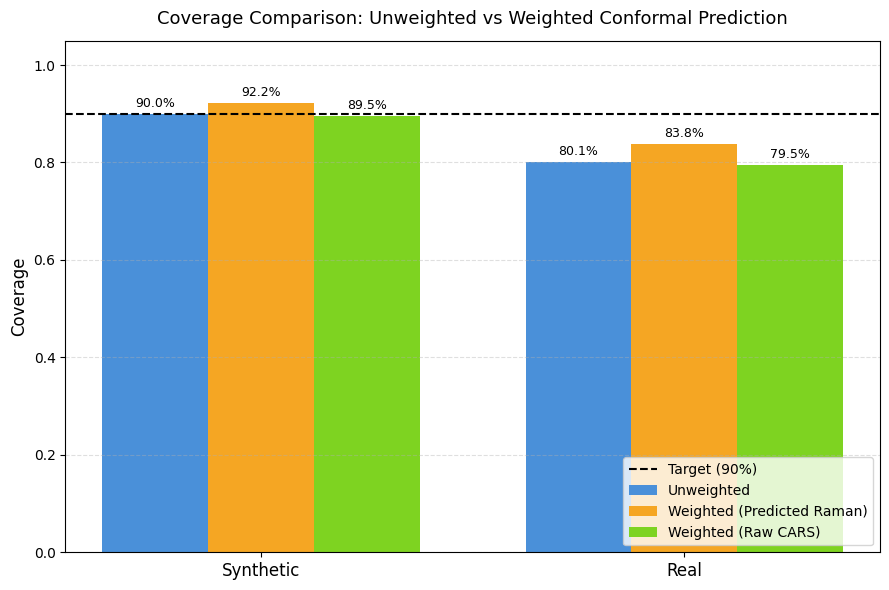

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# === COMPARISON PLOT: Unweighted vs Option A vs Option B ===

# Make sure these have been computed in earlier cells:
# - q_unweighted, q_weighted_A, q_weighted_B
# - cov_syn_unweighted, cov_syn_A, cov_syn_B
# - cov_real_unweighted, cov_real_A, cov_real_B

# Data setup
labels = ["Synthetic", "Real"]
unweighted_vals = [cov_syn_unweighted, cov_real_unweighted]
option_a_vals   = [cov_syn_A, cov_real_A]
option_b_vals   = [cov_syn_B, cov_real_B]

x = np.arange(len(labels))
width = 0.25

# Create figure
fig, ax = plt.subplots(figsize=(9, 6))

# Plot three sets of bars
bars1 = ax.bar(x - width, unweighted_vals, width, label="Unweighted", color="#4A90D9")
bars2 = ax.bar(x,         option_a_vals,   width, label="Weighted (Predicted Raman)", color="#F5A623")
bars3 = ax.bar(x + width, option_b_vals,   width, label="Weighted (Raw CARS)", color="#7ED321")

# Target line
ax.axhline(1 - alpha, linestyle="--", color="black", linewidth=1.5, label=f"Target ({(1-alpha)*100:.0f}%)")

# Add value labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Coverage", fontsize=12)
ax.set_title("Coverage Comparison: Unweighted vs Weighted Conformal Prediction", fontsize=13, pad=12)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=10, frameon=True)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()